In [1]:
#!git pull

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import torch
import gc

/gpfs/projects/imt526a/conda/envs/imt526a-jupyter-torch/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Llama 3.1: 8B
- Resource: https://huggingface.co/meta-llama/Llama-3.1-8B
- Need to login with hf account and request for access to download this package

In [3]:
# from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
# !pip install -U bitsandbytes>=0.46.1

In [4]:
%pip install -q "transformers>=4.46" accelerate bitsandbytes huggingface_hub 2>&1 | tail -2

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os, time, gc
from pathlib import Path
from dataclasses import dataclass

# ── HF cache: prefer the class-shared dir on Tillicum, else default ──
# Setting HF_HOME *before* importing transformers ensures the library
# uses the shared cache for everything (hub downloads, tokenizers, ...).
_shared_cache = Path("/gpfs/projects/imt526a/huggingface")
if _shared_cache.exists():
    os.environ["HF_HOME"] = str(_shared_cache)
    HF_CACHE_DIR = str(_shared_cache)
else:
    HF_CACHE_DIR = None   # falls back to ~/.cache/huggingface

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# ── Device ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Device:    {DEVICE}")
print(f"HF cache:  {HF_CACHE_DIR or '~/.cache/huggingface (default)'}")
if DEVICE == "cuda":
    print(f"GPU:       {torch.cuda.get_device_name(0)}")
    print(f"VRAM:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── HF Hub auth check ────────────────────────────────────────────────────
# Unauthenticated requests are rate-limited on shared-IP environments.
# A class-wide token in /gpfs/projects/imt526a/huggingface/token would be
# picked up via HF_HOME automatically.
_hf_token = (os.environ.get("HF_TOKEN")
             or os.environ.get("HUGGING_FACE_HUB_TOKEN"))
if not _hf_token:
    for candidate in (Path(os.environ.get("HF_HOME", "")) / "token",
                      Path.home() / ".cache" / "huggingface" / "token"):
        if candidate.exists():
            _hf_token = candidate.read_text().strip()
            os.environ["HF_TOKEN"] = _hf_token
            break

print(f"HF auth:   {'token loaded' if _hf_token else 'anonymous (rate-limited)'}")


Device:    cuda
HF cache:  /gpfs/projects/imt526a/huggingface
GPU:       NVIDIA H200
VRAM:      150.1 GB
HF auth:   anonymous (rate-limited)


In [6]:
# # create your own hugging face token and login here
# from huggingface_hub import login
# login("your_token_from_huggingface")

- We use Llama 3.1 8B Instruct loaded with 4-bit quantization for memory-efficient inference/fine-tuning.

In [7]:
def cuda_mem_gb():
    if DEVICE != "cuda":
        return None
    return torch.cuda.memory_allocated() / 1e9

In [8]:
# ── Configuration ────────────────────────────────────────────────────────
MODEL_PRESET = "llama31"   

@dataclass
class Cfg:
    name: str
    hf_id: str
    short: str
    is_chat: bool

PRESETS = {
    "phi2": Cfg(
        "phi-2",
        "microsoft/phi-2",
        "phi2",
        is_chat=False
    ),

    "tinyllama": Cfg(
        "tinyllama",
        "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "tinyllama",
        is_chat=True
    ),

    "llama31": Cfg(
        "llama-3.1-8b",
        "meta-llama/Llama-3.1-8B-Instruct",
        "llama31",
        is_chat=True
    ),
}

cfg = PRESETS[MODEL_PRESET]

print(f"Primary model for §E: {cfg.name} ({cfg.hf_id})")

Primary model for §E: llama-3.1-8b (meta-llama/Llama-3.1-8B-Instruct)


In [9]:
# ── PEFT / LoRA dependencies ─────────────────────────────────────────────
try:
    from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
    HAS_PEFT = True
    print("PEFT:      available")
except ImportError:
    HAS_PEFT = False
    print("PEFT:      not found -- pip install peft")

# ── Wire cfg into the names the QLoRA cell expects ───────────────────────
MODEL_NAME = cfg.hf_id        # "meta-llama/Llama-3.1-8B-Instruct"
device     = torch.device(DEVICE)

print(f"Model:     {MODEL_NAME}")
print(f"Device:    {device}")

PEFT:      available
Model:     meta-llama/Llama-3.1-8B-Instruct
Device:    cuda


In [10]:
def load_slm(hf_id, dtype=torch.float16, device_map="auto",
             quant_config=None, cache_dir=HF_CACHE_DIR):
    """Load an SLM in the specified dtype, optionally quantized.

    cache_dir defaults to the class-shared HF cache (set in §A) so model
    weights are downloaded once for the whole cohort."""
    tokenizer = AutoTokenizer.from_pretrained(
        hf_id, trust_remote_code=True, cache_dir=cache_dir)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    kwargs = dict(device_map=device_map, trust_remote_code=True,
                  cache_dir=cache_dir)
    if quant_config is not None:
        kwargs["quantization_config"] = quant_config
    else:
        kwargs["dtype"] = dtype
    model = AutoModelForCausalLM.from_pretrained(hf_id, **kwargs)
    model.eval()
    return model, tokenizer

def generate_response(model, tokenizer, prompt,
                      max_new_tokens=120, temperature=0.7, do_sample=True,
                      repetition_penalty=1.1, no_repeat_ngram_size=6,
                      seed=0):
    """Plain generation — no stop strings, no chat template.  This is the
    'unfixed' baseline; §F and Assignment Q3 build on it.

    Reproducibility: with `seed` set (default 0) and `do_sample=True`,
    every call with the same (model, prompt) produces the same output.
    `torch.manual_seed` seeds both CPU and CUDA RNG.  Pass `seed=None`
    if you want fresh randomness per call.

    Repetition guards: `repetition_penalty=1.1` and `no_repeat_ngram_size=6`
    prevent the greedy-decoding loop failure mode (`...the answer is the
    answer is...`) that small models reliably fall into without them."""
    if seed is not None:
        torch.manual_seed(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs.input_ids.shape[1]
    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            top_p=0.95,
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            pad_token_id=tokenizer.eos_token_id,
        )
    dt = time.time() - t0
    n_gen = outputs.shape[1] - input_len
    text = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True)
    return text, {"new_tokens": n_gen, "seconds": dt, "tok_per_s": n_gen / dt}

def evaluate_perplexity(model, tokenizer, text):
    """Perplexity of `text` under `model`.  Lower = the model finds the text
    more probable.  Note: a model evaluated on its own generation is biased
    toward low perplexity — see Assignment Q3 Part C."""
    if not text.strip():
        return float("nan")
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model(input_ids=inputs.input_ids, labels=inputs.input_ids)
    return torch.exp(out.loss).item()

def math_trap_solved(text):
    """Objective grader for the Kahneman apple/orange trap (§D).
    The correct answer is apple=$1.05, orange=$0.05.  Returns True iff
    both values appear as numeric tokens in the response.

    Uses lookbehind to avoid matching the middle of a longer number
    (so '11.05' doesn't trigger a 1.05 match) and word boundary at end.
    Accepts an optional leading '$' or '0' on the orange value."""
    has_apple  = bool(re.search(r"(?<!\d)\$?1\.05\b",  text))
    has_orange = bool(re.search(r"(?<!\d)\$?0?\.05\b", text))
    return has_apple and has_orange

def cuda_mem_gb():
    if DEVICE != "cuda":
        return None
    return torch.cuda.memory_allocated() / 1e9

def free_model(model):
    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

In [11]:
# ── Load both SLMs in FP16 ───────────────────────────────────────────────
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
    base_mem = cuda_mem_gb()
    print(f"Baseline VRAM: {base_mem:.2f} GB")

print("Loading Llama-3.1-8B-Instruct...")
model_id, tokenizer = load_slm("meta-llama/Llama-3.1-8B-Instruct")
if DEVICE == "cuda":
    print(f"  VRAM after Llama-3.1-8B-Instruct:  {cuda_mem_gb():.2f} GB")

Baseline VRAM: 0.00 GB
Loading Llama-3.1-8B-Instruct...


Loading weights: 100%|██████████| 291/291 [00:04<00:00, 59.73it/s]


  VRAM after Llama-3.1-8B-Instruct:  16.06 GB


## Data Processing

### Removing symbols, website URL

In [12]:
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('val_data.csv')

label = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\n|\r|\t", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df['clean'] = train_df['comment_text'].apply(clean_text)
val_df['clean'] = val_df['comment_text'].apply(clean_text)


In [13]:
print(train_df.shape)

train_df.head()

(127656, 10)


,Unnamed: 0,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean
0,41967,6ff62abb9f08ee3d,And more unfounded personal attacks by here a...,0,0,0,0,0,0,and more unfounded personal attacks by here at...
1,155824,c438cd4e8073254a,Gilmore Girls \n\nI'm trying to figure out a f...,0,0,0,0,0,0,gilmore girls i m trying to figure out a few t...
2,17231,2d7e5045431a4c70,What is the need of tagging..when we can impro...,0,0,0,0,0,0,what is the need of tagging when we can improv...
3,82855,ddb267b1a581c366,"03:27, Jun 23, 2005 (UTC)",0,0,0,0,0,0,03 27 jun 23 2005 utc
4,31322,53252a7f4f4bf87d,Inconsistencies \n\nThis article seems to pick...,0,0,0,0,0,0,inconsistencies this article seems to pick and...


### TF-IDF

In [14]:
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(train_df['clean'])
X_val = tfidf.transform(val_df['clean'])

#train
model = OneVsRestClassifier(LogisticRegression())
model.fit(X_train, train_df[label])

#Scores
y_pred = model.predict(X_val)
print(classification_report(val_df[label], y_pred, target_names=label))

               precision    recall  f1-score   support

        toxic       0.92      0.61      0.73      3059
 severe_toxic       0.61      0.28      0.38       311
      obscene       0.92      0.63      0.75      1710
       threat       0.55      0.11      0.19        97
       insult       0.84      0.52      0.64      1590
identity_hate       0.74      0.20      0.32       289

    micro avg       0.89      0.56      0.68      7056
    macro avg       0.76      0.39      0.50      7056
 weighted avg       0.88      0.56      0.68      7056
  samples avg       0.06      0.05      0.05      7056



/gpfs/projects/imt526a/conda/envs/imt526a-jupyter-torch/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/gpfs/projects/imt526a/conda/envs/imt526a-jupyter-torch/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/gpfs/projects/imt526a/conda/envs/imt526a-jupyter-torch/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to con

In [15]:
macro_f1 = f1_score(val_df[label], y_pred, average='macro', zero_division=0)
per_label = f1_score(val_df[label], y_pred, average=None, zero_division=0)

print(f"\nMacro F1: {macro_f1:.4f}\n")
for label, score in zip(label, per_label):
    print(f"  {label:<20} {score:.4f}")


Macro F1: 0.5018

  toxic                0.7326
  severe_toxic         0.3805
  obscene              0.7490
  threat               0.1880
  insult               0.6444
  identity_hate        0.3161


### Toxic comment distribution in our dataset


Train Label Distribution
toxic
0    115421
1     12235
Name: count, dtype: int64

Validation Label Distribution
toxic
0    28856
1     3059
Name: count, dtype: int64

Train Percentages
toxic
0    90.415648
1     9.584352
Name: proportion, dtype: float64

Validation Percentages
toxic
0    90.415165
1     9.584835
Name: proportion, dtype: float64


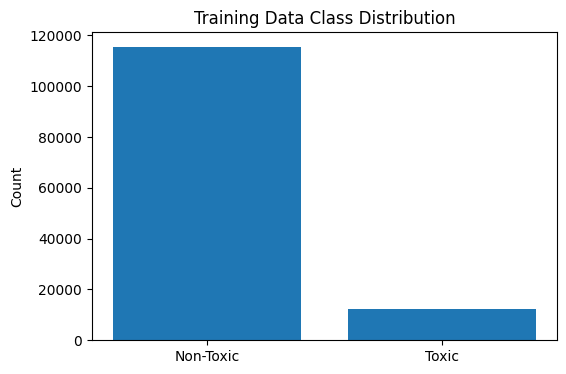

In [16]:
train_counts = train_df['toxic'].value_counts()
val_counts = val_df['toxic'].value_counts()

print("\nTrain Label Distribution")
print(train_counts)

print("\nValidation Label Distribution")
print(val_counts)

# Percentages
train_percent = train_df['toxic'].value_counts(normalize=True) * 100
val_percent = val_df['toxic'].value_counts(normalize=True) * 100

print("\nTrain Percentages")
print(train_percent)

print("\nValidation Percentages")
print(val_percent)

# Plot class imbalance
plt.figure(figsize=(6,4))
plt.bar(['Non-Toxic', 'Toxic'], train_counts.values)
plt.ylabel('Count')
plt.title('Training Data Class Distribution')
plt.show()

- Heavily imbalanced data --> may lead to more non-toxic predictions

In [17]:
# Separate toxic and non-toxic comments
non_toxic_df = train_df[train_df['toxic'] == 0]
toxic_df = train_df[train_df['toxic'] == 1]

# Sample smaller subsets for faster testing
non_toxic_sample = non_toxic_df.sample(5000, random_state=42)
toxic_sample = toxic_df.sample(5000, random_state=42, replace=True)

# Combine text
combined_text = pd.concat([
    non_toxic_sample['comment_text'],
    toxic_sample['comment_text']
])

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)


In [18]:
# create 100 random 
# Randomly sample 100 comments (50 toxic, 50 non-toxic for balance)

sample_toxic     = toxic_df.sample(50, random_state=42, replace=True)
sample_non_toxic = non_toxic_df.sample(50, random_state=42)

# Combine and shuffle
sample_100 = pd.concat([sample_toxic, sample_non_toxic]).sample(frac=1, random_state=42).reset_index(drop=True)

# Keep only the columns you need
sample_100 = sample_100[['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]

# Save to CSV
sample_100.to_csv('sample_100.csv', index=False)

print(f"Saved {len(sample_100)} comments to sample_100.csv")
print(sample_100['toxic'].value_counts())

Saved 100 comments to sample_100.csv
toxic
0    50
1    50
Name: count, dtype: int64


### Creating Similarity Score for toxic comment

In [19]:
combined_text_100 = pd.concat([
    sample_non_toxic['comment_text'],
    sample_toxic['comment_text']
])


X = vectorizer.fit_transform(combined_text_100)

# Split vectors
non_toxic_vectors = X[:len(sample_non_toxic)]
toxic_vectors = X[len(sample_toxic):]

# Toxic centroid
# Average toxic language direction

toxic_centroid = np.asarray(toxic_vectors.mean(axis=0))

# Similarity scores
scores = cosine_similarity(non_toxic_vectors, toxic_centroid)

# Flatten
scores = scores.flatten()

# Add scores to dataframe
non_toxic_sample = sample_non_toxic.copy()
non_toxic_sample['toxicity_similarity'] = scores

# Most suspicious non-toxic examples
suspicious = non_toxic_sample.sort_values(
    by='toxicity_similarity',
    ascending=False
)

# Save with LLaMA scores
suspicious.to_csv('sample_100_similarity.csv', index=False)
print("\nSaved to sample_100_similarity.csv")

print(suspicious[['comment_text', 'toxicity_similarity']].head(100))


Saved to sample_100_similarity.csv
                                             comment_text  toxicity_similarity
104845  Where are your sources? Or proofs? Did you go ...             0.087791
36126   " why don´t you block vandercken he made a""pe...             0.077148
14902   Please stop. If you continue to vandalize Wiki...             0.068577
71270   I... really have nothing left to say. My since...             0.067069
2954    "When editing an article on Wikipedia there is...             0.053364
5717    All the links from this page seem to have been...             0.052749
8104    "\n\n Why no comment? \n\nI started an article...             0.052424
86185        We dont know its not like she can answer you             0.051509
28706   "\n\nMemo to Ernest The Sheep\n(The following ...             0.051132
41707   "Concerning one point of disagreement concerni...             0.046668
40942   Test edits \n\n Please stop making test edits ...             0.046539
24898   "\n\n Pl

## Llama 3.1 8B Baseline

In [20]:
# Split sample_100 into toxic and non-toxic
toxic_subset     = sample_100[sample_100['toxic'] == 1]
non_toxic_subset = sample_100[sample_100['toxic'] == 0]

# Embedding function using LLaMA
def get_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    ).to(model_id.device)                    

    with torch.no_grad():
        outputs = model_id.model(**inputs)   

    embedding = outputs.last_hidden_state.mean(dim=1)
    return embedding.squeeze().detach().float().cpu().numpy()

# Step 1 — Get toxic embeddings
print("Generating toxic embeddings...")
toxic_embeddings = np.array([
    get_embedding(text) for text in toxic_subset['comment_text']
])

# Step 2 — Toxic centroid
llama_toxic_centroid = toxic_embeddings.mean(axis=0)

# Step 3 — Score ALL 100 comments against the toxic centroid
print("Scoring all 100 comments...")
sample_100 = sample_100.copy()
sample_100['llama_similarity'] = [
    cosine_similarity(
        get_embedding(text).reshape(1, -1),
        llama_toxic_centroid.reshape(1, -1)
    )[0][0]
    for text in sample_100['comment_text']
]

# Step 4 — Sort and show
llama_suspicious = sample_100.sort_values(by='llama_similarity', ascending=False)
print(llama_suspicious[['comment_text', 'toxic', 'llama_similarity']].head(20))

# Save with LLaMA scores
sample_100.to_csv('sample_100_compared.csv', index=False)
print("\nSaved to sample_100_compared.csv")

Generating toxic embeddings...
Scoring all 100 comments...
                                         comment_text  toxic  llama_similarity
58  Hey you fucking nigger whore, I'm removing com...      1          0.932596
26  I consider you calling me a vandal a personal ...      1          0.892973
86  This clown is a fucking faggot that doesn't kn...      1          0.887356
31  To the humongous faggot pro-russian administra...      1          0.882463
73  "\n\nLook there are clearly more ""people"" he...      1          0.880179
39  You are such a dickwad. She did it, we all wat...      1          0.868804
41  let me tell you little man, a personal attack ...      1          0.866568
6   "\n\nYou still blow me off. If you are not eve...      1          0.860197
80  " why don´t you block vandercken he made a""pe...      0          0.858644
9   """Please do not add defamatory content to Wik...      1          0.858428
13  You're being a jerk! \n\nWhy do you insist on ...      1          0.

# Run validation set

In [21]:
# Run validation set

# print("Scoring validation set...")
# val_df['llama_similarity'] = [
#     cosine_similarity(
#         get_embedding(text).reshape(1, -1),
#         llama_toxic_centroid.reshape(1, -1)
#     )[0][0]
#     for text in val_df['comment_text']
# ]

# val_df.to_csv('val_df_with_llama.csv', index=False)
# print("Saved!")

In [22]:
val_df = pd.read_csv('val_df_with_llama.csv')
print("Loaded!")

Loaded!


In [23]:
threshold = 0.7
val_df['llama_pred'] = (val_df['llama_similarity'] >= threshold).astype(int)

# Evaluate
print(classification_report(val_df['toxic'], val_df['llama_pred']))
macro_f1 = f1_score(val_df['toxic'], val_df['llama_pred'], average='macro', zero_division=0)
print(f"Macro F1: {macro_f1:.4f}")


              precision    recall  f1-score   support

           0       0.96      0.39      0.55     28856
           1       0.13      0.83      0.22      3059

    accuracy                           0.43     31915
   macro avg       0.54      0.61      0.38     31915
weighted avg       0.88      0.43      0.52     31915

Macro F1: 0.3837


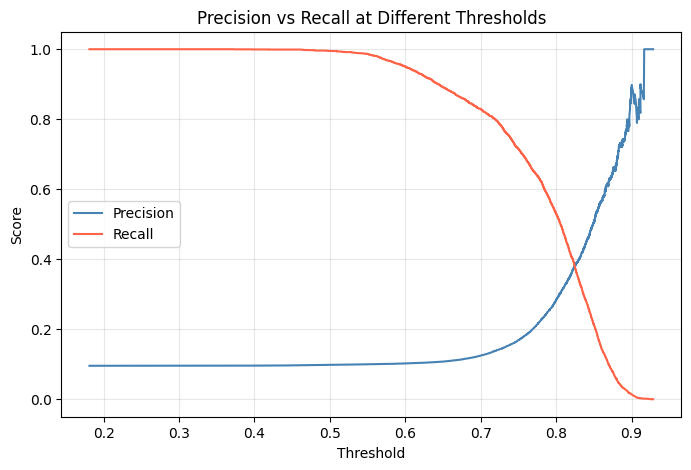

Best threshold: 0.8223
Best F1:        0.3853


In [24]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(val_df['toxic'], val_df['llama_similarity'])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall[:-1], label='Recall', color='tomato')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find threshold with best F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1:        {f1_scores[best_idx]:.4f}")

In [25]:
# try with new threshold

threshold = 0.8
val_df['llama_pred'] = (val_df['llama_similarity'] >= threshold).astype(int)

# Evaluate
print(classification_report(val_df['toxic'], val_df['llama_pred']))
macro_f1 = f1_score(val_df['toxic'], val_df['llama_pred'], average='macro', zero_division=0)
print(f"Macro F1: {macro_f1:.4f}")

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     28856
           1       0.28      0.53      0.37      3059

    accuracy                           0.83     31915
   macro avg       0.61      0.69      0.63     31915
weighted avg       0.88      0.83      0.85     31915

Macro F1: 0.6349


In [26]:
val_df['tfidf_pred'] = y_pred[:, 0]  # toxic column only

# Now check the columns exist
print(val_df.columns.tolist())

['Unnamed: 0', 'id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'clean', 'tfidf_pred', 'llama_similarity', 'llama_pred']


In [27]:
# Compare between tf-idf and Llama 

from sklearn.metrics import classification_report, f1_score, roc_auc_score

# TF-IDF results
tfidf_f1 = f1_score(val_df['toxic'], val_df['tfidf_pred'], average='macro', zero_division=0)

# LLaMA results 
llama_f1 = f1_score(val_df['toxic'], val_df['llama_pred'], average='macro', zero_division=0)

print("=" * 45)
print(f"{'Model':<20} {'Macro F1':>10}")
print("=" * 45)
print(f"{'TF-IDF + LR':<20} {tfidf_f1:>10.4f}")
print(f"{'LLaMA 3.1 8B':<20} {llama_f1:>10.4f}")
print("=" * 45)

Model                  Macro F1
TF-IDF + LR              0.8548
LLaMA 3.1 8B             0.6349


# Zero-shot

In [28]:
# sampling 500 to test whether llama has the ability to classify toxic / non-toxic
toxic_sample = val_df[val_df['toxic'] == 1].sample(n = 250, random_state = 42)
non_toxic_sample = val_df[val_df['toxic'] == 0].sample(n = 250, random_state = 42)

zero_df = pd.concat([toxic_sample, non_toxic_sample]).sample(frac = 1, random_state = 42).reset_index(drop = True)

In [29]:
def make_prompt(text):
    return f"""
    Classify the following comment as toxic or non-toxic.
    
    Return only one number:
    1 = toxic
    0 = non-toxic
    
    Comment:
    {text}
    
    Answer:
    """

In [30]:
from tqdm import tqdm

def zero_shot_predict(text, model, tokenizer):
    prompt = make_prompt(text)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    answer = decoded.split("Answer:")[-1].strip()

    if answer.startswith("1"):
        return 1
    elif answer.startswith("0"):
        return 0
    else:
        return 0  # fallback

In [31]:
# prediction
preds = []

for text in tqdm(zero_df["comment_text"]):
    pred = zero_shot_predict(text, model_id, tokenizer)
    preds.append(pred)

zero_df["zero_shot_pred"] = preds

  0%|          | 0/500 [00:00<?, ?it/s][transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
100%|██████████| 500/500 [00:48<00:00, 10.28it/s]


In [32]:
from sklearn.metrics import precision_score, recall_score

y_true = zero_df["toxic"]
y_pred = zero_df["zero_shot_pred"]

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Toxic F1:", f1_score(y_true, y_pred, pos_label=1))
print("Toxic Precision:", precision_score(y_true, y_pred, pos_label=1))
print("Toxic Recall:", recall_score(y_true, y_pred, pos_label=1))

print(classification_report(y_true, y_pred))

Macro F1: 0.9099823565418822
Toxic F1: 0.9112426035502958
Toxic Precision: 0.8988326848249028
Toxic Recall: 0.924
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       250
           1       0.90      0.92      0.91       250

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



**Macro F1: 0.908, indicating that instruction-tuned LLM has strong general understanding in toxicity**

# Qlora

In [33]:
# §M -- QLoRA backend detection.
# bitsandbytes (CUDA) integrates with transformers from_pretrained().
# mps-bitsandbytes uses its own quantize_model() after loading; it also
# ships its own BitsAndBytesConfig (not the transformers one).
HAS_BNB = False
BNB_FLAVOR = None
if HAS_PEFT:
    try:
        import bitsandbytes  # noqa: F401
        from transformers import BitsAndBytesConfig
        HAS_BNB = True
        BNB_FLAVOR = "bitsandbytes (CUDA)"
    except ImportError:
        try:
            # mps-bitsandbytes: load model first, then call quantize_model().
            # BitsAndBytesConfig and quantize_model come from this package, not transformers.
            from mps_bitsandbytes import BitsAndBytesConfig, quantize_model as bnb_quantize_model
            HAS_BNB = True
            BNB_FLAVOR = "mps-bitsandbytes (Apple Silicon)"
        except ImportError:
            pass

if HAS_BNB:
    print(f"QLoRA backend: {BNB_FLAVOR}")
else:
    print("Skipping §M -- install bitsandbytes (CUDA) or mps-bitsandbytes (Apple Silicon)")

QLoRA backend: bitsandbytes (CUDA)


In [34]:
if HAS_BNB:
    import warnings
    from peft import prepare_model_for_kbit_training
    warnings.filterwarnings("ignore", category=FutureWarning, module="bitsandbytes")

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    print(f"Loading {MODEL_NAME} in 4-bit (NF4) via {BNB_FLAVOR}...")
    qmodel = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        cache_dir=HF_CACHE_DIR,
        token=_hf_token,
    )
    qmodel = prepare_model_for_kbit_training(qmodel, use_gradient_checkpointing=False)

    qlora = get_peft_model(qmodel, LoraConfig(
        r=8, lora_alpha=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Llama-specific
        lora_dropout=0.05, bias="none",
        task_type=TaskType.CAUSAL_LM,
    ))
    qlora.print_trainable_parameters()

Loading meta-llama/Llama-3.1-8B-Instruct in 4-bit (NF4) via bitsandbytes (CUDA)...


Loading weights: 100%|██████████| 291/291 [00:05<00:00, 49.89it/s]


trainable params: 6,815,744 || all params: 8,037,076,992 || trainable%: 0.0848


In [35]:
from torch.utils.data import Dataset, DataLoader

def make_prompt_qlora(text, label=None):
    prompt = f"""Classify the following comment as toxic or non-toxic.

Return only one number:
1 = toxic
0 = non-toxic

Comment:
{text}

Answer:
"""

    if label is not None:
        prompt += f"{label}"

    return prompt


class ToxicPromptDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        text = row["comment_text"]
        label = str(row["toxic"])

        prompt = f"""Classify the following comment as toxic or non-toxic.

Return only one number:
1 = toxic
0 = non-toxic

Comment:
{text}

Answer:
"""

        full_text = prompt + label

        full_enc = self.tokenizer(
            full_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        prompt_enc = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = full_enc["input_ids"].squeeze(0)
        attention_mask = full_enc["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # mask prompt tokens, answer 0/1
        prompt_len = prompt_enc["input_ids"].shape[1]
        labels[:prompt_len] = -100

        # mask padding
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }
        
if HAS_BNB:
    # balanced train sample
    toxic_train = train_df[train_df["toxic"] == 1].sample(1000, random_state=42)
    non_toxic_train = train_df[train_df["toxic"] == 0].sample(1000, random_state=42)
    
    fine_tune_df = pd.concat([toxic_train, non_toxic_train]) \
        .sample(frac=1, random_state=42) \
        .reset_index(drop=True)
    
    # balanced validation sample
    toxic_val = val_df[val_df["toxic"] == 1].sample(250, random_state=42)
    non_toxic_val = val_df[val_df["toxic"] == 0].sample(250, random_state=42)
    
    qlora_val_df = pd.concat([toxic_val, non_toxic_val]) \
        .sample(frac=1, random_state=42) \
        .reset_index(drop=True)
    
    
    train_loader = DataLoader(
        ToxicPromptDataset(fine_tune_df, tokenizer),
        batch_size=4,
        shuffle=True
    )
    
    val_loader = DataLoader(
        ToxicPromptDataset(qlora_val_df, tokenizer),
        batch_size=4,
        shuffle=False
    )
    
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 500 | Val batches: 125


## training

In [36]:
import os
if os.path.exists("best_qlora_checkpoint"):
    print("Checkpoint found, skipping training!")
    print(os.listdir("best_qlora_checkpoint"))
else:
    if HAS_BNB:
        opt = torch.optim.AdamW(
            [p for p in qlora.parameters() if p.requires_grad],
            lr=5e-5
        )
    
        num_epochs = 2
        epoch_losses = {}
    
        best_val_loss = float("inf")
        best_epoch = None
    
        for epoch in range(1, num_epochs + 1):
            # ---------- Train ----------
            qlora.train()
            train_losses = []
    
            for step, batch in enumerate(train_loader):
                batch = {k: v.to(device) for k, v in batch.items()}
    
                opt.zero_grad(set_to_none=True)
    
                out = qlora(**batch)
                loss = out.loss
    
                loss.backward()
                opt.step()
    
                train_losses.append(loss.item())
    
                if step % 20 == 0:
                    print(f"Epoch {epoch} step {step:3d} train loss {loss.item():.4f}")
    
            avg_train_loss = sum(train_losses) / len(train_losses)
    
            # ---------- Validate ----------
            qlora.eval()
            val_losses = []
    
            with torch.no_grad():
                for batch in val_loader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    out = qlora(**batch)
                    val_losses.append(out.loss.item())
    
            avg_val_loss = sum(val_losses) / len(val_losses)
            epoch_losses[epoch] = avg_val_loss
    
            print(f"\nEpoch {epoch}")
            print(f"Train loss: {avg_train_loss:.4f}")
            print(f"Val CE loss: {avg_val_loss:.4f}")
    
            # ---------- Save only best checkpoint ----------
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_epoch = epoch
    
                qlora.save_pretrained("best_qlora_checkpoint")
                tokenizer.save_pretrained("best_qlora_checkpoint")
    
                print(f"Saved new best checkpoint at epoch {epoch}")
    
            print()
    
        print("=" * 40)
        for ep, loss in epoch_losses.items():
            marker = " ◄ best" if ep == best_epoch else ""
            print(f"Epoch {ep} CE loss: {loss:.4f}{marker}")
        print("=" * 40)
    
        print(f"Best epoch: {best_epoch}")
        print(f"Best val CE loss: {best_val_loss:.4f}")
    
    else:
        print("bitsandbytes backend not available — skipping QLoRA training.")

Checkpoint found, skipping training!
['adapter_model.safetensors', 'tokenizer_config.json', 'chat_template.jinja', 'adapter_config.json', 'README.md', 'tokenizer.json']


## Prediction

In [37]:
from peft import PeftModel

best_qlora = PeftModel.from_pretrained(
    qmodel,
    "best_qlora_checkpoint"
)
best_qlora.eval()

/gpfs/projects/imt526a/conda/envs/imt526a-jupyter-torch/lib/python3.14/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.

In [38]:
def qlora_predict(text, model, tokenizer):
    prompt = make_prompt_qlora(text, label=None)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(model.device)

    model.eval()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = decoded.split("Answer:")[-1].strip()

    # safer parsing
    for ch in answer:
        if ch == "1":
            return 1
        elif ch == "0":
            return 0

    return 0

In [39]:
if os.path.exists("qlora_predictions.csv"):
    print("Already exists, loading from file!")
    qlora_val_df = pd.read_csv("qlora_predictions.csv")
else:
    qlora_preds = []
    
    tokenizer.padding_side = 'left'
    for text in tqdm(qlora_val_df["comment_text"]):
        pred = qlora_predict(text, best_qlora, tokenizer)
        qlora_preds.append(pred)
    
    qlora_val_df["qlora_pred"] = qlora_preds
    qlora_val_df.to_csv("qlora_predictions.csv", index=False)

Already exists, loading from file!


In [40]:
y_true = qlora_val_df["toxic"]
y_pred = qlora_val_df["qlora_pred"]

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Toxic F1:", f1_score(y_true, y_pred, pos_label=1))
print("Toxic Precision:", precision_score(y_true, y_pred, pos_label=1))
print("Toxic Recall:", recall_score(y_true, y_pred, pos_label=1))

print(classification_report(y_true, y_pred))

Macro F1: 0.8994190444004571
Toxic F1: 0.9070631970260223
Toxic Precision: 0.8472222222222222
Toxic Recall: 0.976
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       250
           1       0.85      0.98      0.91       250

    accuracy                           0.90       500
   macro avg       0.91      0.90      0.90       500
weighted avg       0.91      0.90      0.90       500



## Findings
Although the Macro F1 score did not show a significant improvement compared to the zero-shot baseline, the QLoRA fine-tuned model achieved a noticeably higher toxic recall. This suggests that the model became more likely to predict comments as toxic, which helped reduce missed toxic comments but also slightly lowered precision.

# Final Model Run

In [41]:
#load the dataset

test_df = pd.read_csv('test.csv')
test_df['clean'] = test_df['comment_text'].apply(clean_text)
test_df.head()

# Load files
test_labels = pd.read_csv('test_labels.csv')



In [46]:
# Drop -1 rows from test_labels
test_labels_valid = test_labels[test_labels['toxic'] != -1].reset_index(drop=True)

# Filter test.csv to only keep matching IDs
test_valid = test_df[test_df['id'].isin(test_labels_valid['id'])].reset_index(drop=True)

print(f"test_labels valid rows: {len(test_labels_valid)}")
print(f"test_scored rows: {len(test_valid)}")
test_valid.head()

test_labels valid rows: 63978
test_scored rows: 63978


,id,comment_text,clean
0,0001ea8717f6de06,Thank you for understanding. I think very high...,thank you for understanding i think very highl...
1,000247e83dcc1211,:Dear god this site is horrible.,dear god this site is horrible
2,0002f87b16116a7f,"""::: Somebody will invariably try to add Relig...",somebody will invariably try to add religion r...
3,0003e1cccfd5a40a,""" \n\n It says it right there that it IS a typ...",it says it right there that it is a type the t...
4,00059ace3e3e9a53,""" \n\n == Before adding a new product to the l...",before adding a new product to the list make s...


In [47]:
half = len(test_scored) // 2

part1 = test_valid.iloc[:half].reset_index(drop=True)
part2 = test_valid.iloc[half:].reset_index(drop=True)

part1.to_csv('test_run_part1.csv', index=False)
part2.to_csv('test_run_part2.csv', index=False)

print(f"Part 1: {len(part1)} rows → mei")
print(f"Part 2: {len(part2)} rows → vvn")

Part 1: 31989 rows → mei
Part 2: 31989 rows → vvn


# mei run this

In [48]:
df = pd.read_csv('test_run_part1.csv')
df['clean'] = df['comment_text'].apply(clean_text)
df.head()

,id,comment_text,clean
0,0001ea8717f6de06,Thank you for understanding. I think very high...,thank you for understanding i think very highl...
1,000247e83dcc1211,:Dear god this site is horrible.,dear god this site is horrible
2,0002f87b16116a7f,"""::: Somebody will invariably try to add Relig...",somebody will invariably try to add religion r...
3,0003e1cccfd5a40a,""" \n\n It says it right there that it IS a typ...",it says it right there that it is a type the t...
4,00059ace3e3e9a53,""" \n\n == Before adding a new product to the l...",before adding a new product to the list make s...


In [49]:
# import os

# CHUNK_SIZE = 1000
# output_file = 'test_part1_predictions.csv'

# if os.path.exists(output_file):
#     done_df = pd.read_csv(output_file)
#     start_idx = len(done_df)
#     print(f"Resuming from index {start_idx}")
# else:
#     start_idx = 0
#     print("Starting fresh")

# for start in tqdm(range(start_idx, len(df), CHUNK_SIZE)):
#     chunk = df.iloc[start : start + CHUNK_SIZE]
#     preds = [qlora_predict(text, best_qlora, tokenizer) for text in chunk["comment_text"]]
#     chunk = chunk.copy()
#     chunk["qlora_pred"] = preds
#     chunk.to_csv(output_file, mode='a', header=(start == 0), index=False)

# print("Done!")

Starting fresh


  0%|          | 0/32 [00:14<?, ?it/s]


KeyboardInterrupt: 

# vvn run this 

In [ ]:
# df_part2 = pd.read_csv('test_run_part2.csv')
# df_part2['clean'] = df_part2['comment_text'].apply(clean_text)
# df_part2.head()

In [ ]:
# import os

# CHUNK_SIZE = 1000
# output_file = 'test_part2_predictions.csv'

# if os.path.exists(output_file):
#     done_df = pd.read_csv(output_file)
#     start_idx = len(done_df)
#     print(f"Resuming from index {start_idx}")
# else:
#     start_idx = 0
#     print("Starting fresh")

# for start in tqdm(range(start_idx, len(df_part2), CHUNK_SIZE)):
#     chunk = df_part2.iloc[start : start + CHUNK_SIZE]
#     preds = [qlora_predict(text, best_qlora, tokenizer) for text in chunk["comment_text"]]
#     chunk = chunk.copy()
#     chunk["qlora_pred"] = preds
#     chunk.to_csv(output_file, mode='a', header=(start == 0), index=False)

# print("Done!")

# Split the data

# identify the patterens 

In [ ]:
# Load test labels and your predictions
# test_labels = pd.read_csv('test_labels.csv')
# test_labels.head()

In [ ]:
# Find rows where any column is 1
toxic_any = test_labels[(test_labels[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']] == 1).any(axis=1)]
#print(toxic_any)

In [ ]:
# # Create new column, default 0
# test_labels['test_label'] = 0

# # Set to 1 where any column is 1
# test_labels.loc[(test_labels[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']] == 1).any(axis=1), 'test_label'] = 1

# print(test_labels['test_label'].value_counts())

In [ ]:
# test_labels.head()

In [ ]:
# test_df.head()

In [ ]:
# from sklearn.metrics import classification_report

# # Check which ids match and which don't
# in_both = set(results_df['id']) & set(test_labels['id'])
# only_results = set(results_df['id']) - set(test_labels['id'])
# only_labels = set(test_labels['id']) - set(results_df['id'])

# print(f"IDs in both: {len(in_both)}")
# print(f"IDs only in results_df: {len(only_results)}")
# print(f"IDs only in test_labels: {len(only_labels)}")

In [ ]:
#!git status

In [ ]:
!git add project.ipynb test_run_part1.csv test_run_part2.csv
!git commit -m "split data final lmao"

In [ ]:
#!git push

In [ ]:
#!git add best_qlora_checkpoint
#!git commit -m "Add best qlora checkpoint"
#!git push